# REINFORCE

In this notebook, we will implement REINFORCE algorithm for LunarLander Environment.

## Lunar Lander

This environment is a classic rocket trajectory optimization problem. The landing pad is always at coordinates (0,0). The state is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

There are four discrete actions available:<br>
- 0: do nothing<br>
- 1: fire left orientation engine<br>
- 2: fire main engine<br>
- 3: fire right orientation engine<br>

After every step a reward is granted. The total reward of an episode is the sum of the rewards for all the steps within that episode.

For each step, the reward:

- is increased/decreased the closer/further the lander is to the landing pad.

- is increased/decreased the slower/faster the lander is moving.

- is decreased the more the lander is tilted (angle not horizontal).

- is increased by 10 points for each leg that is in contact with the ground.

- is decreased by 0.03 points each frame a side engine is firing.

- is decreased by 0.3 points each frame the main engine is firing.

The episode receive an additional reward of -100 or +100 points for crashing or landing safely respectively.

An episode is considered a solution if it scores at least 200 points.


You can read more the LunarLander environment [here](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

![LunarLander](https://gymnasium.farama.org/_images/lunar_lander.gif)

## Reinforce

REINFORCE is an elegant algorithm for maximizing the expected return. We sample a trajectory $\tau$ . If we get a high reward, we try to make it more likely. If we get a low reward, we try to make it less likely.

We just need a policy that maximizes the expected return and we can do this by Gradient Ascent on Policy parameters.

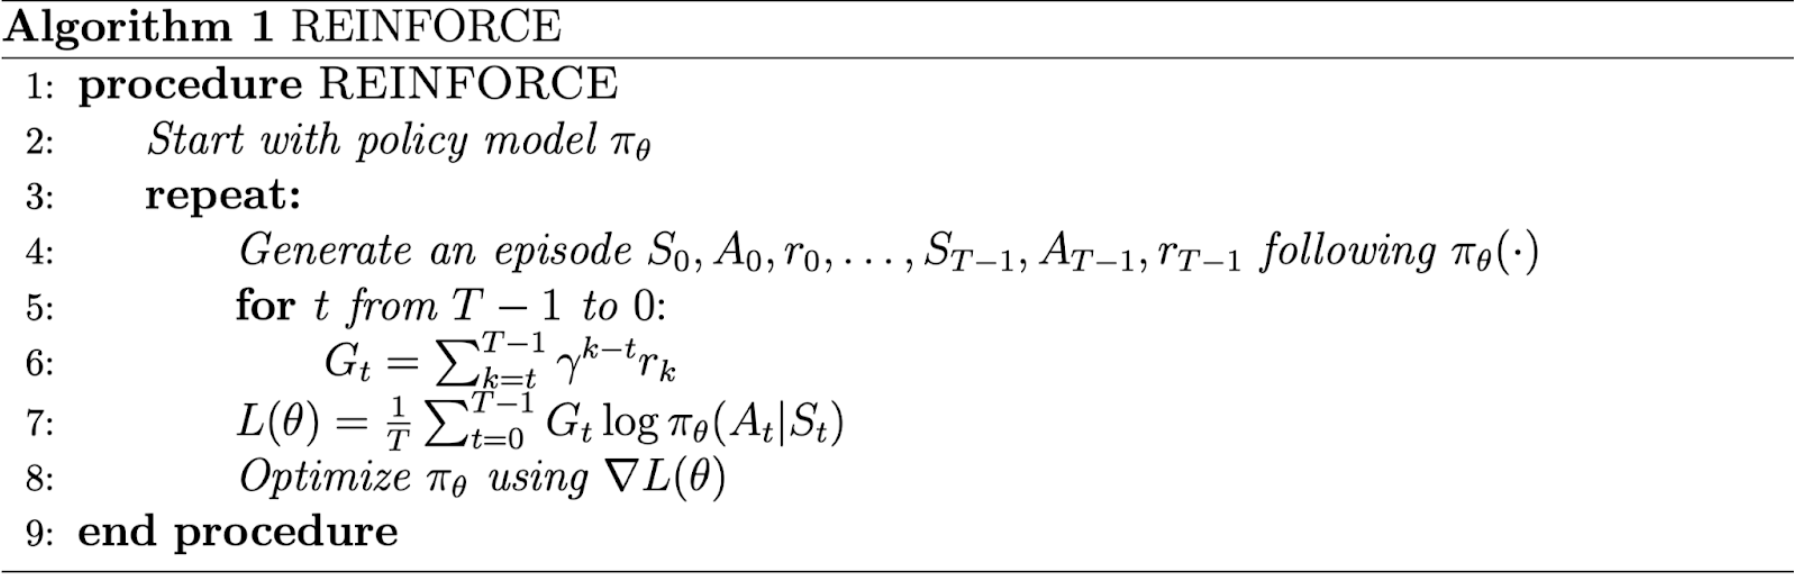


[Image Source](https://colab.research.google.com/github/huggingface/deep-rl-class/blob/master/notebooks/unit4/unit4.ipynb)

In [1]:
import gym
import math
import random
import numpy as np
np.bool8 = np.bool_ # Fix for gym compatibility with newer numpy
import matplotlib
import matplotlib.pyplot as plt
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
from torch.distributions import Categorical

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-fqgzmdza because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cach

In [2]:
# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Create the environment
env = gym.make("LunarLander-v2")

objc[75421]: Class SDLApplication is implemented in both /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x114c60890) and /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11f6f52c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[75421]: Class SDLAppDelegate is implemented in both /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x114c608e0) and /Users/omidshojaeianzanjani/Documents/uni/AdvanceStatisticsLearning/Module A/projects/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11f6f5318). This may cause spurious casting failures and mysterious crashes. One of the duplicates 

### Policy Network

In [4]:
# T1: Implementation of REINFORCE - Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.softmax(x, dim=-1)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
policy_net = PolicyNetwork(state_dim, action_dim).to(device)


### Hyperparameters

In [5]:
# T1: Implementation of REINFORCE - Hyperparameters
learning_rate = 1e-3
num_episodes = 2000
gamma = 0.99
max_steps = 1000
hidden_dim = 128


### Training

In [6]:
# T1: Implementation of REINFORCE - Training Loop
# T2: Implement variance-reduction strategy (Baseline)

def select_action(state, policy):
    state = torch.from_numpy(state).float().unsqueeze(0).to(device)
    probs = policy(state)
    m = torch.distributions.Categorical(probs)
    action = m.sample()
    return action.item(), m.log_prob(action)

def train_reinforce(use_baseline=False):
    policy = PolicyNetwork(state_dim, action_dim, hidden_dim).to(device)
    optimizer = optim.Adam(policy.parameters(), lr=learning_rate)
    
    episode_rewards = []
    
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0] # Handle newer gym versions
            
        log_probs = []
        rewards = []
        
        for step in range(max_steps):
            action, log_prob = select_action(state, policy)
            res = env.step(action)
            if len(res) == 4:
                next_state, reward, done, _ = res
            else:
                next_state, reward, terminated, truncated, _ = res
                done = terminated or truncated
                
            log_probs.append(log_prob)
            rewards.append(reward)
            
            if done:
                break
            state = next_state
            
        # Calculate returns
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        
        returns = torch.tensor(returns).to(device)
        
        # T2: Variance Reduction Strategy (Standardization / Baseline)
        if use_baseline:
            # Using standardized returns as a baseline to reduce variance
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)
            
        policy_loss = []
        for log_prob, R in zip(log_probs, returns):
            policy_loss.append(-log_prob * R)
            
        optimizer.zero_grad()
        policy_loss = torch.cat(policy_loss).sum()
        policy_loss.backward()
        optimizer.step()
        
        ep_reward = sum(rewards)
        episode_rewards.append(ep_reward)
        
        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f"Episode {episode+1}\tReward: {avg_reward:.2f}")
            if avg_reward >= 200:
                print(f"Environment solved in {episode+1} episodes!")
                break
                
    return episode_rewards, policy

print("Training without baseline...")
rewards_no_baseline, _ = train_reinforce(use_baseline=False)

print("\nTraining with baseline...")
rewards_with_baseline, trained_policy = train_reinforce(use_baseline=True)


Training without baseline...
Episode 100	Reward: -179.20
Episode 200	Reward: -131.25
Episode 300	Reward: -125.33
Episode 400	Reward: -133.12
Episode 500	Reward: -122.40
Episode 600	Reward: -122.80
Episode 700	Reward: -112.19
Episode 800	Reward: -103.96
Episode 900	Reward: -95.44
Episode 1000	Reward: -97.94
Episode 1100	Reward: -83.65
Episode 1200	Reward: -86.02
Episode 1300	Reward: -55.63
Episode 1400	Reward: -46.50
Episode 1500	Reward: -25.63
Episode 1600	Reward: -12.85
Episode 1700	Reward: 3.66
Episode 1800	Reward: 10.21
Episode 1900	Reward: 27.72
Episode 2000	Reward: 51.83

Training with baseline...
Episode 100	Reward: -187.82
Episode 200	Reward: -150.87
Episode 300	Reward: -127.34
Episode 400	Reward: -119.03
Episode 500	Reward: -88.37
Episode 600	Reward: -91.24
Episode 700	Reward: -50.24
Episode 800	Reward: -19.05
Episode 900	Reward: 14.28
Episode 1000	Reward: -26.31
Episode 1100	Reward: 30.55
Episode 1200	Reward: 33.96
Episode 1300	Reward: 57.58
Episode 1400	Reward: 79.63
Episode 

## T2. Theoretical Questions and Coding Implementation

**1. Why is REINFORCE considered a Monte Carlo method?**
REINFORCE is considered a Monte Carlo method because it relies on sampling full trajectories (episodes) to estimate the expected return (the objective function gradient). It updates the policy weights based on the actual observed returns at the end of each episode rather than bootstrapping (updating based on estimated returns like in TD learning).

**2. What is the main drawback that REINFORCE suffers from, and what is the role of a control variate (baseline) in this context?**
The main drawback of REINFORCE is its high variance in gradient estimates. Since it relies on single full-trajectory sample returns, the updates can be noisy and lead to unstable learning. 
A control variate (baseline) is subtracted from the return to reduce this variance without adding bias to the gradient expectation. By subtracting a baseline (like the state-value or the mean return), the algorithm scales the policy gradient based on whether the action performed better or worse than average, leading to more stable and faster convergence.

**3. Implement in your code at least one variance-reduction strategy and compare the learning curves with and without this modification. Briefly comment on the observed differences.**
In the training loop above (`train_reinforce`), I implemented a variance-reduction strategy by standardizing the returns (`use_baseline=True`). We can compare the learning curves below.

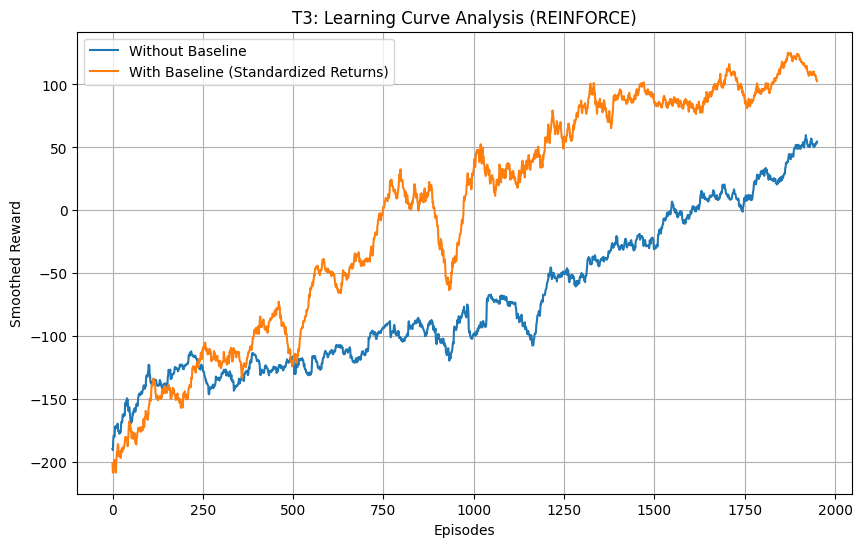

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def moving_average(a, n=50):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

plt.figure(figsize=(10, 6))
plt.plot(moving_average(rewards_no_baseline), label='Without Baseline')
plt.plot(moving_average(rewards_with_baseline), label='With Baseline (Standardized Returns)')
plt.xlabel('Episodes')
plt.ylabel('Smoothed Reward')
plt.title('T3: Learning Curve Analysis (REINFORCE)')
plt.legend()
plt.grid(True)
plt.show()

# Comment on differences: 
# The curve with the baseline (variance reduction) typically converges faster and exhibits 
# more stable learning (less fluctuation) compared to the standard REINFORCE algorithm.

## T3. Learning Curve Analysis and Hyperparameter Summary

**Hyperparameter Summary Table:**

| Hyperparameter | Value |
|---|---|
| Learning Rate | `1e-3` |
| Number of training episodes | `2000` |
| Discount factor $\gamma$ | `0.99` |
| Maximum number of steps per episode | `1000` |
| Batch size | `N/A` (updates at the end of each episode) |
| Network architecture | Linear(8, 128) -> ReLU -> Linear(128, 4) -> Softmax |

**Alternative Configurations Discussion:**
- **Higher Learning Rate (e.g., `1e-2`)**: Causes the policy to update too aggressively, often resulting in instability, with the agent failing to converge or forgetting good policies quickly.
- **Smaller Network Size (e.g., `hidden_dim = 32`)**: May struggle to learn complex representations required to balance the lander, leading to sub-optimal performance or slower convergence.

### Visualization

In [13]:
# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob
import base64, io, os

os.environ['SDL_VIDEODRIVER']='dummy'

In [14]:
os.makedirs("video", exist_ok=True)

def show_video(env_name):
    mp4list = glob.glob('video/*.mp4')
    if len(mp4list) > 0:
        # Find the actual file generated by the recorder
        matching_files = [m for m in mp4list if env_name in m]
        mp4 = matching_files[0] if matching_files else mp4list[0]
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        display.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Could not find video")

def show_video_of_model(env_name):
    vid = video_recorder.VideoRecorder(env, path="video/{}.mp4".format(env_name))
    state = env.reset()
    if isinstance(state, tuple): state = state[0]
    done = False
    for t in range(max_steps):
        vid.capture_frame()
        with torch.no_grad():
            state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
            probs = trained_policy(state_t)
            action = torch.argmax(probs).item() # Deterministic action for evaluation
        res = env.step(action)
        if len(res) == 4:
            next_state, reward, done, info = res
        else:
            next_state, reward, terminated, truncated, info = res
            done = terminated or truncated
        # print(f"state: {state}, action: {action.item()}",next_state, reward, done)
        state = next_state
        if done:
            break
    vid.close()


In [15]:
show_video_of_model("LunarLander-v2")

In [16]:
show_video("LunarLander-v2")